In [1]:
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import PIL
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam # - Works
import random
from glob import glob
import seaborn as sns
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import matplotlib.pyplot as plt
import matplotlib.image as img
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
print(gpus)
try:
    tf.config.experimental.set_memory_growth = True
except Exception as ex:
    print(e)

[]


In [3]:
! rm -rf /kaggle/working/data/

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import pathlib

base_dir = pathlib.Path('/content/drive/MyDrive/Skin Cancer/Skin_Cancer')
train_dir = base_dir / 'Train'
test_dir = base_dir / 'Test'


In [6]:
image_count_train = len(list(data_dir_train.glob('*/*.jpg')))
print(image_count_train)
image_count_test = len(list(data_dir_test.glob('*/*.jpg')))
print(image_count_test)

NameError: name 'data_dir_train' is not defined

In [7]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Path to the folders
train_path = Path('/content/drive/MyDrive/Skin Cancer/Skin_Cancer/Train')
test_path = Path('/content/drive/MyDrive/Skin Cancer/Skin_Cancer/Test')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

print("Classes:", train_ds.class_names)


Found 2247 files belonging to 9 classes.
Found 118 files belonging to 9 classes.
Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


In [9]:
data_dir_train = Path('/content/drive/MyDrive/Skin Cancer/Skin_Cancer/Train')
data_dir_test = Path('/content/drive/MyDrive/Skin Cancer/Skin_Cancer/Test')

# Step 3: Count images
image_count_train = len(list(data_dir_train.glob('*/*.jpg')))
image_count_test = len(list(data_dir_test.glob('*/*.jpg')))

# Step 4: Display counts
print("Number of training images:", image_count_train)
print("Number of testing images:", image_count_test)

Number of training images: 2247
Number of testing images: 118


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2247 files belonging to 9 classes.
Classes found: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


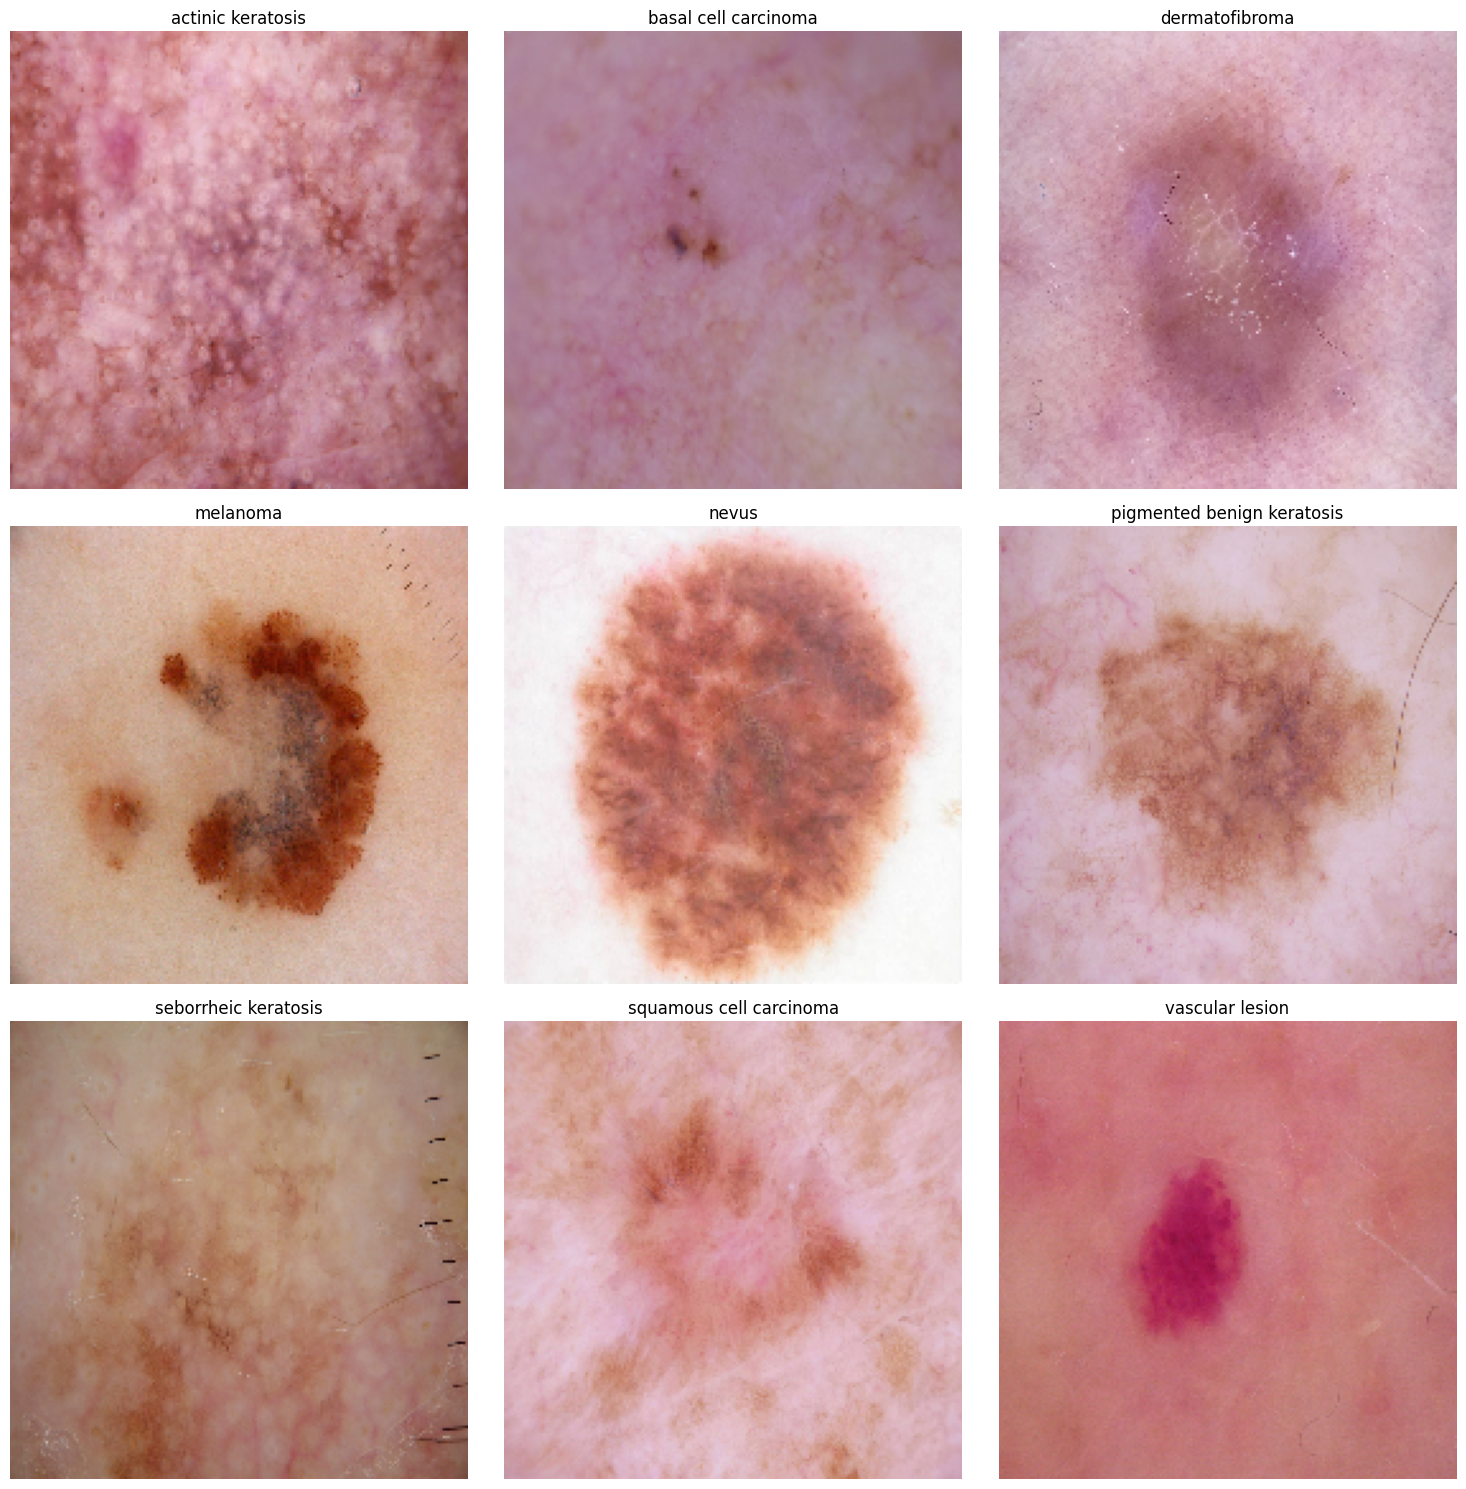

In [10]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.utils import load_img

# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Set path
data_dir_train = Path('/content/drive/MyDrive/Skin Cancer/Skin_Cancer/Train')

# Step 3: Load dataset
image_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_train,
    batch_size=32,
    image_size=(180, 180),
    label_mode='categorical',
    seed=123
)

# Step 4: Get class names
class_names = image_dataset.class_names
print("Classes found:", class_names)

# Step 5: Create dictionary of image paths
files_path_dict = {}
for c in class_names:
    folder = data_dir_train / c
    files_path_dict[c] = [str(folder / f) for f in os.listdir(folder) if f.endswith('.jpg')]

# Step 6: Visualize one sample image per class
plt.figure(figsize=(15, 15))
for idx, c in enumerate(class_names):
    path = files_path_dict[c][0]  # first image in class
    plt.subplot(3, 3, idx + 1)
    plt.imshow(load_img(path, target_size=(180, 180)))
    plt.title(c)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [11]:
def class_distribution_count(directory):

    #count number of image in each classes
    count= []
    for path in pathlib.Path(directory).iterdir():
        if path.is_dir():
            count.append(len([name for name in os.listdir(path)
                               if os.path.isfile(os.path.join(path, name))]))

    #name of the classes
    sub_directory = [name for name in os.listdir(directory)
                    if os.path.isdir(os.path.join(directory, name))]

    #return dataframe with image count and class.
    return pd.DataFrame(list(zip(sub_directory,count)),columns =['Class', 'No. of Image'])

df = class_distribution_count(data_dir_train)
df

,Class,No. of Image
0,actinic keratosis,114
1,melanoma,438
2,squamous cell carcinoma,181
3,basal cell carcinoma,376
4,seborrheic keratosis,77
5,nevus,365
6,dermatofibroma,95
7,pigmented benign keratosis,462
8,vascular lesion,139


<Axes: xlabel='No. of Image', ylabel='Class'>

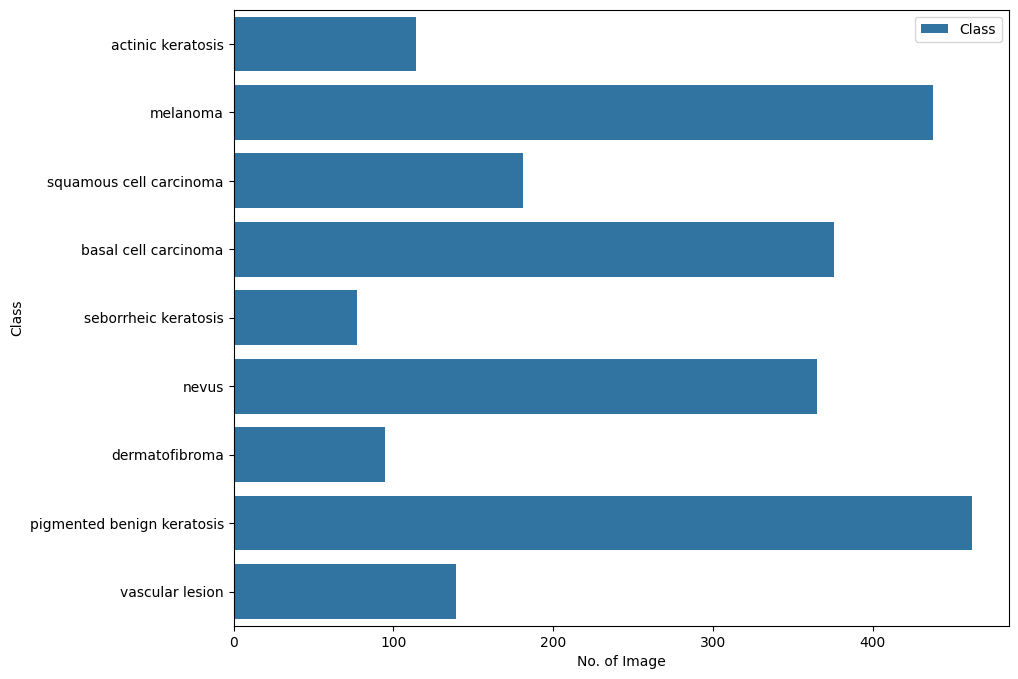

In [12]:
#Visualize the Number of image in each class.
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.barplot(x="No. of Image", y="Class", data=df,
            label="Class")

In [13]:
#install Augmentor
!pip install Augmentor

In [14]:
import Augmentor
!cp -r "/content/drive/MyDrive/Skin Cancer/Skin_Cancer/Train" /content/
path_to_training_dataset = "/content/Train/"

# Define your class names if not already done
class_names = os.listdir(path_to_training_dataset)

# Loop through each class and apply augmentation
for class_name in class_names:
    p = Augmentor.Pipeline(path_to_training_dataset + class_name)
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.sample(500)  # Generate 500 images per class


Initialised with 77 image(s) found.
Output directory set to /content/Train/seborrheic keratosis/output.

Processing <PIL.Image.Image image mode=RGB size=1024x768 at 0x7A1894C1A410>: 100%|██████████| 500/500 [00:42<00:00, 11.75 Samples/s]


Initialised with 438 image(s) found.
Output directory set to /content/Train/melanoma/output.

Processing <PIL.Image.Image image mode=RGB size=3072x2304 at 0x7A1894BF5110>: 100%|██████████| 500/500 [01:27<00:00,  5.69 Samples/s]


Initialised with 462 image(s) found.
Output directory set to /content/Train/pigmented benign keratosis/output.

...

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7A1894C32FD0>: 100%|██████████| 500/500 [00:15<00:00, 31.35 Samples/s]


Initialised with 376 image(s) found.
Output directory set to /content/Train/basal cell carcinoma/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7A1894BF50D0>: 100%|██████████| 500/500 [00:16<00:00, 30.17 Samples/s]


Initialised with 181 image(s) found.
Output directory set to /content/Train/squamous cell carcinoma/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7A1894DA98D0>: 100%|██████████| 500/500 [00:17<00:00, 29.10 Samples/s]


In [15]:
from pathlib import Path

# Set the path to the training directory
data_dir_train = Path('/content/Train')  # This is your copied and augmented dataset path

# Count all .jpg images in class folders (excluding output folders)
image_count_train = len(list(data_dir_train.glob('*/*.jpg')))
print("Total training images (including augmented):", image_count_train)


Total training images (including augmented): 2247


In [16]:
# Count only augmented images (inside output folders)
augmented_image_count = len(list(data_dir_train.glob('*/output/*.jpg')))
print("Augmented images only:", augmented_image_count)


Augmented images only: 4500


In [17]:
import tensorflow as tf
from pathlib import Path

# Your training data path (now includes original + augmented images)
data_dir_train = Path('/content/Train')

# Define common parameters
batch_size = 32
img_size = (180, 180)
seed = 123

# Load training dataset (80%)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_train,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

# Load validation dataset (20%)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_train,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

# Check class names
class_names = train_ds.class_names
print("Classes:", class_names)


Found 6747 files belonging to 9 classes.
Using 5398 files for training.
Found 6747 files belonging to 9 classes.
Using 1349 files for validation.
Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


In [18]:
import tensorflow as tf

# Assuming data_dir_train is the path to your dataset directory
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_train,
    batch_size=32,
    image_size=(180, 180),
    label_mode='categorical',
    seed=123,
    validation_split=0.2,
    subset="validation",  # This will pick the validation data from the split
    shuffle=True,  # Optional, but typically you'd want to shuffle the data
)

# You can also load the training dataset similarly
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir_train,
    batch_size=32,
    image_size=(180, 180),
    label_mode='categorical',
    seed=123,
    validation_split=0.2,
    subset="training",  # This will pick the training data from the split
    shuffle=True,  # Optional, shuffling the data is usually a good idea
)


Found 6747 files belonging to 9 classes.
Using 1349 files for validation.
Found 6747 files belonging to 9 classes.
Using 5398 files for training.


In [19]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

# Optimizing the training dataset
train_ds = train_ds.cache() \
                   .shuffle(1000) \
                   .prefetch(buffer_size=AUTOTUNE)

# Optimizing the validation dataset
val_ds = val_ds.cache() \
               .prefetch(buffer_size=AUTOTUNE)


In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Create the Sequential model
model = models.Sequential()

# Rescaling layer to normalize pixel values
model.add(layers.Rescaling(1./255, input_shape=(180, 180, 3)))

# First convolutional layer (32 filters, kernel size 3x3, ReLU activation)
model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2, 2)))

# Second convolutional layer (64 filters, kernel size 3x3, ReLU activation)
model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2, 2)))

# Third convolutional layer (128 filters, kernel size 3x3, ReLU activation)
model.add(layers.Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2, 2)))

# Dropout layer to reduce overfitting (50% dropout rate)
model.add(layers.Dropout(0.5))

# Flatten the 3D tensor to 1D vector for Dense layers
model.add(layers.Flatten())

# First dense layer with 128 units and ReLU activation
model.add(layers.Dense(128, activation='relu'))

# Dropout layer after the dense layer (25% dropout rate)
model.add(layers.Dropout(0.25))

# Output layer with softmax activation for multi-class classification
# `len(class_names)` should be the number of classes in your dataset
model.add(layers.Dense(len(class_names), activation='softmax'))

# Print the model summary to see the details of the layers
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,648,137 (25.36 MB)

 Trainable params: 6,648,137 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

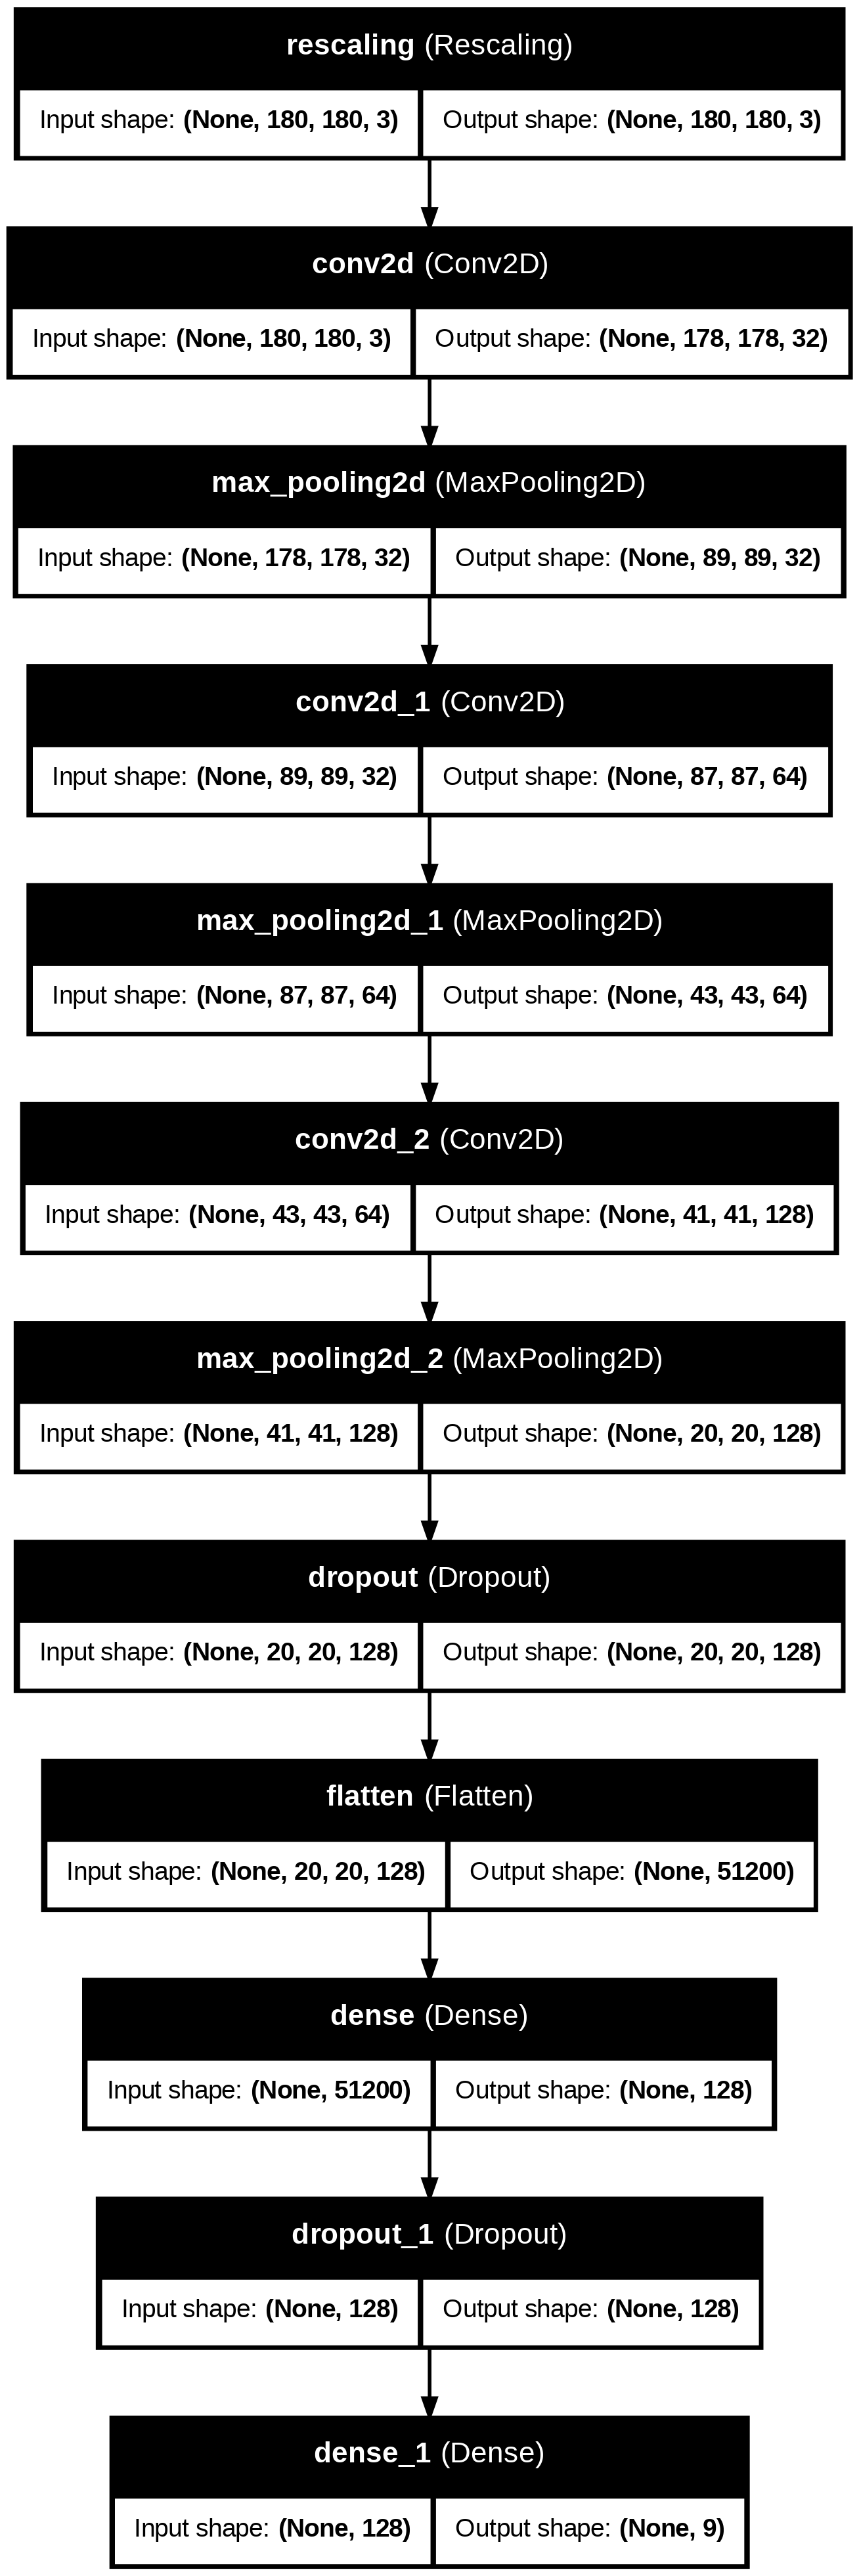

In [21]:
from tensorflow.keras.utils import plot_model

# Plot the model architecture and save it as a PNG file
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)


In [22]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Compile the model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# ModelCheckpoint callback to save the best model based on validation accuracy
checkpoint = ModelCheckpoint("model.h5", monitor="val_accuracy", save_best_only=True, mode="auto", verbose=1)

# EarlyStopping callback to stop training when the validation accuracy stops improving
earlystop = EarlyStopping(monitor="val_accuracy", patience=5, mode="auto", verbose=1)


In [23]:
# Number of epochs to train the model
epochs = 20

# Train the model with the train and validation datasets, using the checkpoint and early stopping callbacks
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[checkpoint, earlystop]
)


Epoch 1/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2385 - loss: 1.9739
Epoch 1: val_accuracy improved from -inf to 0.47220, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 436s 2s/step - accuracy: 0.2390 - loss: 1.9728 - val_accuracy: 0.4722 - val_loss: 1.5182
Epoch 2/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4310 - loss: 1.5182
Epoch 2: val_accuracy improved from 0.47220 to 0.47665, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.4311 - loss: 1.5179 - val_accuracy: 0.4766 - val_loss: 1.4361
Epoch 3/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5107 - loss: 1.3307
Epoch 3: val_accuracy improved from 0.47665 to 0.52261, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.5107 - loss: 1.3305 - val_accuracy: 0.5226 - val_loss: 1.3376
Epoch 4/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5435 - loss: 1.2397
Epoch 4: val_accuracy improved from 0.52261 to 0.55893, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 389s 2s/step - accuracy: 0.5436 - loss: 1.2393 - val_accuracy: 0.5589 - val_loss: 1.1979
Epoch 5/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5908 - loss: 1.0889
Epoch 5: val_accuracy improved from 0.55893 to 0.64196, saving model to model.h5


...

169/169 ━━━━━━━━━━━━━━━━━━━━ 397s 2s/step - accuracy: 0.8391 - loss: 0.4515 - val_accuracy: 0.7843 - val_loss: 0.7387
Epoch 14/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8534 - loss: 0.4137
Epoch 14: val_accuracy improved from 0.78428 to 0.80504, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 399s 2s/step - accuracy: 0.8533 - loss: 0.4138 - val_accuracy: 0.8050 - val_loss: 0.7074
Epoch 15/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8538 - loss: 0.4021
Epoch 15: val_accuracy did not improve from 0.80504
169/169 ━━━━━━━━━━━━━━━━━━━━ 457s 2s/step - accuracy: 0.8538 - loss: 0.4022 - val_accuracy: 0.8013 - val_loss: 0.7240
Epoch 16/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8731 - loss: 0.3574
Epoch 16: val_accuracy improved from 0.80504 to 0.81690, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 415s 2s/step - accuracy: 0.8731 - loss: 0.3575 - val_accuracy: 0.8169 - val_loss: 0.7368
Epoch 17/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8763 - loss: 0.3179
Epoch 17: val_accuracy improved from 0.81690 to 0.82135, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 400s 2s/step - accuracy: 0.8763 - loss: 0.3181 - val_accuracy: 0.8213 - val_loss: 0.6893
Epoch 18/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8847 - loss: 0.3148
Epoch 18: val_accuracy improved from 0.82135 to 0.83247, saving model to model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 441s 2s/step - accuracy: 0.8848 - loss: 0.3148 - val_accuracy: 0.8325 - val_loss: 0.7170
Epoch 19/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8771 - loss: 0.3311
Epoch 19: val_accuracy did not improve from 0.83247
169/169 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.8771 - loss: 0.3311 - val_accuracy: 0.7821 - val_loss: 0.9146
Epoch 20/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8813 - loss: 0.3210
Epoch 20: val_accuracy did not improve from 0.83247
169/169 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.8813 - loss: 0.3209 - val_accuracy: 0.7984 - val_loss: 0.7784


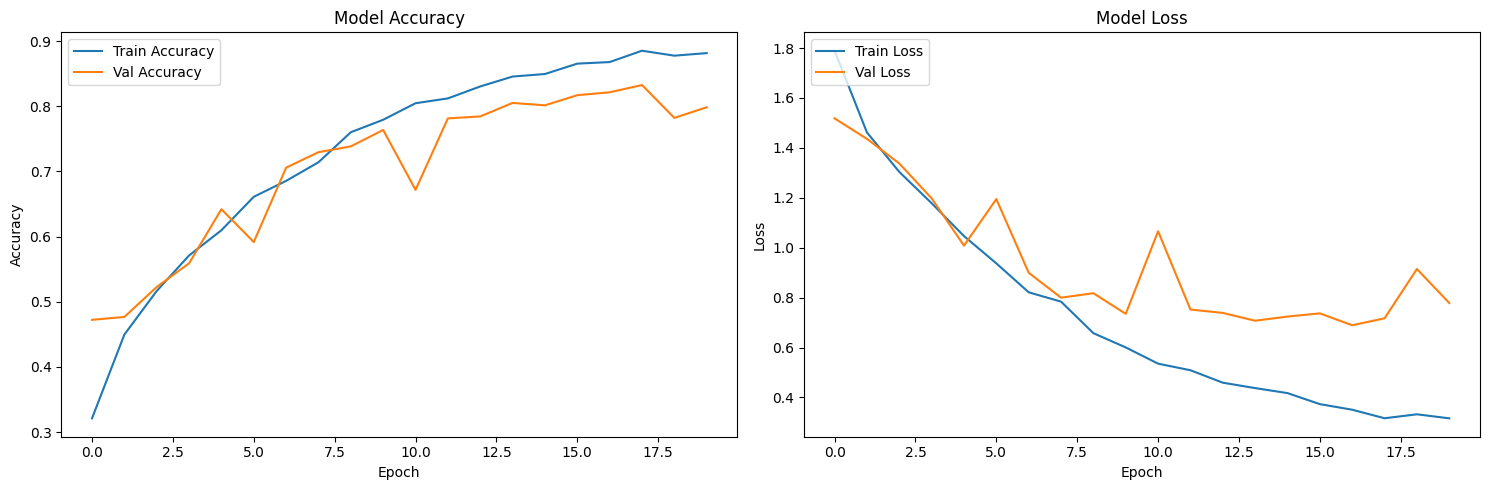

In [25]:
import matplotlib.pyplot as plt

# Fix: dynamically get number of epochs from history
epochs_range = range(len(history.history['accuracy']))

plt.figure(figsize=(15, 5))

# Plot Model Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Train Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# Plot Model Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Train Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step
Actual Class: basal cell carcinoma
Predicted Class: melanoma


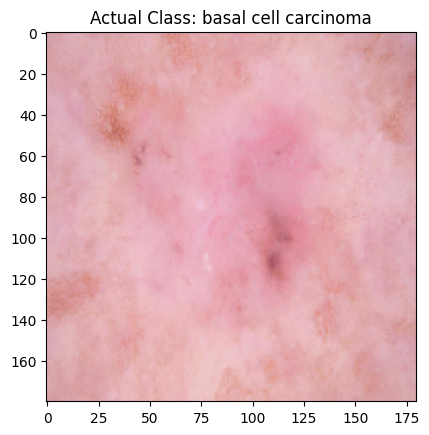

In [26]:
import os
import numpy as np
from glob import glob
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt

# Pick the last image in class folder for testing
test_image_path = os.path.join(data_dir_test, class_names[1], '*')
test_image_files = glob(test_image_path)
test_image = load_img(test_image_files[-1], target_size=(180, 180))  # size only, not channels
plt.imshow(test_image)
plt.grid(False)
plt.title("Actual Class: " + class_names[1])

# Preprocess image
img_array = img_to_array(test_image) / 255.0  # normalize
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
pred = model.predict(img_array)
pred_class_index = np.argmax(pred)
pred_class = class_names[pred_class_index]

# Print result
print("Actual Class: " + class_names[1])
print("Predicted Class: " + pred_class)
